In [1]:
import sys
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

from src.io import load_data
from src.feature import annotate_labels, our_feature
from src.utils import (
    diff_cycles,
    savgol_smooth,
    nanmax,
    nanmin,
    nanmean,
    nanskew,
    nanvar,
    nankurtosis,
)
from src.learning import random_fit_and_eval, set_seed


## Load Data

In [2]:
data_folder = '/data/Blob_EastUS/xiaofan/battery/all_temp_new/data/raw'
data = load_data(data_folder)

fixed_labels = annotate_labels(data, label_mode='fixed')
relative_labels = annotate_labels(data, label_mode='relative')

Loading cells:   0%|          | 0/151 [00:00<?, ?it/s]

Loading cells: 100%|██████████| 151/151 [09:07<00:00,  3.63s/it]


In [3]:
xps_df = pd.read_csv('/data/Blob_EastUS/xiaofan/battery/all_temp_new/data/xps_data.csv', index_col=0)
y_fixed = [fixed_labels[x] for x in xps_df.date_tag]
y_rel = [relative_labels[x] for x in xps_df.date_tag]
xps_df = xps_df.assign(**{
    'CO': xps_df['C1s'] + xps_df['O1s'],
    'PF': xps_df['P2p'] + xps_df['F1s'],
    'CO/(CO+PF)': (xps_df['C1s'] + xps_df['O1s']) / (
        xps_df['C1s'] + xps_df['O1s'] + xps_df['P2p'] + xps_df['F1s']
    ),
    'life_fixed': y_fixed,
    'life_relative': y_rel,
    'temperature': xps_df.temp1
})
xps_target_columns = [
    'Li1s', 'C1s', 'O1s', 'F1s',
    'P2p', 'Ni3p1', 'Co3p1', 'Mn3p',
    'CO', 'PF', 'CO/(CO+PF)'
]
xps_df = xps_df[
    ['date_tag', 'type', 'life_fixed', 'life_relative', 'temperature'] + xps_target_columns
]

In [4]:
aggregated_data = []
for tag, g in xps_df.groupby(['date_tag', 'type']):
    g_imputed = SimpleImputer(strategy='median').fit_transform(g[xps_target_columns])
    numbers = KMeans(1, n_init=10).fit(g_imputed).cluster_centers_[0]
    aggregated_data.append(g.values[0, :5].tolist() + numbers.tolist())
xps_df_agg = pd.DataFrame(aggregated_data, columns=xps_df.columns)

to_study = xps_df_agg[xps_df_agg.type == 'E']
cols_to_study = xps_target_columns[:-3]

## Plot the clusters generated by the Kmeans model

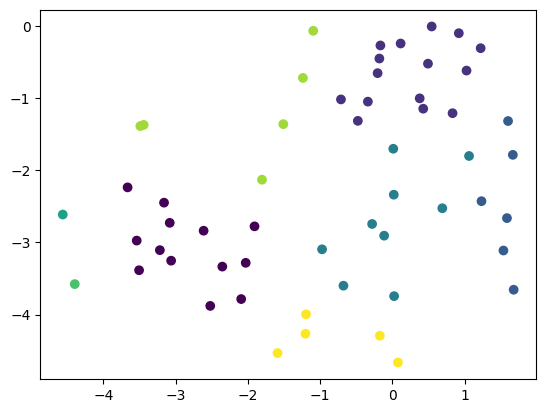

,Li1s,C1s,O1s,F1s,P2p,Ni3p1,Co3p1,Mn3p
0,21.366923,32.980000,24.451846,14.800154,4.492154,1.037846,0.785077,0.037538
1,27.584800,22.354400,31.771067,12.771600,3.142067,0.935067,1.420800,0.057067
2,32.561000,18.134333,25.597333,17.761333,2.859833,0.703000,2.353667,0.042667
3,27.033778,23.652222,25.940889,17.484222,3.657444,0.878444,1.561333,0.053111
4,3.620000,42.030000,33.076000,17.632000,1.888000,0.718000,0.426000,0.962000
5,18.000000,51.434000,17.158000,10.156000,1.656000,0.636000,0.862000,0.098000
6,24.794333,30.549000,30.682667,9.312333,2.505833,0.887000,0.646333,0.012000
7,25.456000,25.879200,19.643200,22.399600,4.365200,0.976400,1.244800,0.035600


In [5]:
# load cluster
import pickle

with open('/data/Blob_EastUS/xiaofan/battery/all_temp_new/data/clusters.pkl', 'rb') as f:
    centers, clusters = pickle.load(f)
    
plt.scatter(
    *TSNE().fit_transform(to_study[cols_to_study]).T, c=clusters
)
plt.show()

pd.DataFrame(centers, columns=cols_to_study)

In [6]:
from IPython.display import display
omit_clusters = []

for center, (gid, g) in zip(centers, to_study.groupby(clusters)):
    print(f'Group {gid}:')

    display(pd.DataFrame({
        k: [v] for k, v in zip(cols_to_study, center)
    }, index=['Cluster center']))
    if len(g) <= 1:
        omit_clusters.append(gid)
    display(g)

Group 0:


,Li1s,C1s,O1s,F1s,P2p,Ni3p1,Co3p1,Mn3p
Cluster center,21.366923,32.98,24.451846,14.800154,4.492154,1.037846,0.785077,0.037538


,date_tag,type,life_fixed,life_relative,temperature,Li1s,C1s,O1s,F1s,P2p,Ni3p1,Co3p1,Mn3p,CO,PF,CO/(CO+PF)
38,0202-3_4,E,110,159,25,20.766,33.630,27.310,12.786,3.676,1.086,0.720,0.026,60.940,16.462,0.787074
40,0202-3_5,E,68,106,25,18.774,33.524,25.534,15.128,4.958,1.016,1.034,0.036,59.058,20.086,0.746375
46,0909-1_3,E,608,509,70,20.656,36.706,21.818,13.618,5.070,0.866,0.736,0.090,58.524,18.688,0.758241
50,0909-1_7,E,719,501,70,22.730,30.240,21.812,17.832,5.454,0.926,0.684,0.108,52.052,23.286,0.690711
52,0909-2_2,E,420,353,70,21.806,32.080,20.896,17.800,4.944,1.432,1.000,0.038,52.976,22.744,0.698596
54,0909-2_6,E,659,486,70,23.240,31.106,23.276,15.752,5.088,0.830,0.656,0.054,54.382,20.840,0.722738
78,1013-5_2,E,127,169,30,21.200,33.828,25.690,13.634,3.888,0.998,0.730,0.036,59.518,17.522,0.772685
80,1013-5_3,E,153,213,30,19.842,33.572,24.728,15.534,4.610,1.112,0.602,0.006,58.300,20.144,0.742968
82,1013-5_4,E,128,182,30,18.864,35.810,24.670,13.884,4.822,1.038,0.874,0.032,60.480,18.706,0.763888
100,1013-6_5,E,134,157,30,20.538,37.384,27.028,9.944,2.852,1.408,0.848,0.000,64.412,12.796,0.834954


Group 1:


,Li1s,C1s,O1s,F1s,P2p,Ni3p1,Co3p1,Mn3p
Cluster center,27.5848,22.3544,31.771067,12.7716,3.142067,0.935067,1.4208,0.057067


...

,Li1s,C1s,O1s,F1s,P2p,Ni3p1,Co3p1,Mn3p
Cluster center,24.794333,30.549,30.682667,9.312333,2.505833,0.887,0.646333,0.012


,date_tag,type,life_fixed,life_relative,temperature,Li1s,C1s,O1s,F1s,P2p,Ni3p1,Co3p1,Mn3p,CO,PF,CO/(CO+PF)
14,0202-1_7,E,9,47,25,25.876,28.410,29.002,11.718,3.572,0.634,0.786,0.000,57.412,15.290,0.790284
26,0202-2_6,E,32,60,25,24.776,29.060,27.328,13.894,3.204,1.038,0.700,0.002,56.388,17.098,0.766761
86,1013-5_6,E,148,203,30,26.626,27.026,34.146,8.412,2.178,1.004,0.604,0.002,61.172,10.590,0.852432
88,1013-5_7,E,133,201,30,26.040,27.564,31.456,10.922,2.400,0.884,0.576,0.052,59.020,13.189,0.818959
96,1013-6_3,E,194,238,30,23.748,35.920,31.082,5.920,1.872,0.892,0.572,0.000,67.002,7.792,0.895892
98,1013-6_4,E,246,246,30,21.700,35.314,31.082,5.008,1.809,0.870,0.640,0.016,66.396,6.988,0.907652


Group 7:


,Li1s,C1s,O1s,F1s,P2p,Ni3p1,Co3p1,Mn3p
Cluster center,25.456,25.8792,19.6432,22.3996,4.3652,0.9764,1.2448,0.0356


,date_tag,type,life_fixed,life_relative,temperature,Li1s,C1s,O1s,F1s,P2p,Ni3p1,Co3p1,Mn3p,CO,PF,CO/(CO+PF)
24,0202-2_4,E,4,12,25,19.912,26.866,24.132,23.768,3.454,1.142,0.676,0.048,50.998,27.222,0.651598
44,0909-1_2,E,850,692,70,28.216,22.586,15.548,26.150,4.564,0.634,2.224,0.086,38.134,30.714,0.553442
48,0909-1_5,E,760,523,70,25.504,28.520,18.758,20.440,4.874,0.770,1.116,0.016,47.278,25.314,0.649729
58,0909-3_4,E,471,344,70,26.114,27.994,20.122,18.994,4.694,1.028,1.044,0.008,48.116,23.688,0.670004
110,1227-6_3,E,543,397,55,27.534,23.430,19.656,22.646,4.240,1.308,1.164,0.020,43.086,26.886,0.613232


## Build Feature and target

In [7]:

X_add =np.array([[
        [cycle_data['Q_d'][-1], cycle_data['Q_c'][-1]]
         for cycle_data in data[cell][:50]]
    for cell in to_study['date_tag']]
)

def get_slope_intercept(y):
    x = np.linspace(1, len(y), len(y))
    z = np.polyfit(x, y, 1)
    return z

intercept = []
for i in range(X_add.shape[0]):
    intercept.append([get_slope_intercept(X_add[i, :, 0]), get_slope_intercept(X_add[i, :, 1])])
intercept = np.array(intercept)
intercept = intercept.reshape(intercept.shape[0], -1)



X_xps = []
for cell in to_study['date_tag']:
    cell_data = data[cell]
    x = torch.stack([
        torch.stack([
            cycle_data['VQ_c'], cycle_data['VQ_d'],
            cycle_data['dVdQ_c'], cycle_data['dVdQ_d'], 
            cycle_data['interp_I_c'], cycle_data['interp_I_d'],
            cycle_data['interp_V_c'], cycle_data['interp_V_d'],
            cycle_data['QV_c'], cycle_data['QV_d'],
            cycle_data['interp_E_c'], cycle_data['interp_E_d'],
            cycle_data['interp_W_c'], cycle_data['interp_W_d']
        ]) for cycle_data in cell_data[:50]
    ])
    X_xps.append(x)
X_xps = torch.stack(X_xps).permute(0, 2, 1, 3).contiguous()
y = clusters
omit_clusters = [4,5]
mask = np.isin(y, omit_clusters, invert=True)

X_xps, y = X_xps[mask], y[mask]

unique_labels = np.unique(y)
label_mapping = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}
y = np.array([label_mapping[label] for label in y])

X_ours,feature_names = our_feature(
    X_xps,
    num_cycle_groups=5,
    num_signal_segments=4,
    aggregators=[
        nankurtosis, nanmax, nanmin, nanmean, nanvar, nanskew
    ],
    activators=[
        lambda x: x,  # identity
        torch.abs
    ],
    smoothers=None,
    curve_differ=None,
    device='cpu',
    build_feature_name=True
)
X_ours = np.nan_to_num(X_ours, nan=0., posinf=0., neginf=0.)

# Plot function

In [8]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

def plot_auroc(y_test, y_score, save_fig_path = None, seed=None, mask_font=False):
    plt.figure()
    main_colors = ['#5a9bd5', '#ed7d31', '#70ad46', '#a5a5a5']
    darker_colors = ['#4473c5', '#c55b11', '#538234', '#7c7c7c']

    plt.rcParams.update({"font.size":14})

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4, 5])

    n_classes = 6
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Compute macro-average ROC curve and ROC area
    # First aggregate all false positive rates
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

    # Then interpolate all ROC curves at this points
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    # Finally average it and compute AUC
    mean_tpr /= n_classes

    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # Plot all ROC curves
    plt.figure(figsize=(8, 6))
    micro_label = ' '*40 if mask_font else 'micro-average(area = {0:0.2f})'.format(roc_auc["micro"])
    macro_label = ' '*40 if mask_font else 'macro-average(area = {0:0.2f})'.format(roc_auc["macro"])

    plt.plot(fpr["micro"], tpr["micro"],
            label=micro_label,
            color=main_colors[1],  linestyle='-', linewidth=2)

    plt.plot(fpr["macro"], tpr["macro"],
            label=macro_label,
            color=darker_colors[1],  linestyle='-', linewidth=2)
            
    markers = cycle(['o', 'v', '^', '<', '>', 's'])
    # linestyles = cycle(['solid', 'dashdot', 'dashed', (0, (1, 1)), 'dotted',  (0, (1, 5))])
    linestyles = cycle(['dashed'])
    # colors = cycle([ '#004d40','#5086C4', '#4C6C43','#7C7CBA','#3FA0C0','#00A664'])
    colors = cycle([ '#004d40', '#5F9C61','#A4C97C','#81d4fa','#0288d1','#01579b' ])

    for i, color, linestyle in zip(range(n_classes), colors,  linestyles):
        label = ' '*40 if mask_font else 'class {0} (area = {1:0.2f})'.format(i, roc_auc[i])
        plt.plot(fpr[i], tpr[i], color=color,  lw=1, linestyle=linestyle,
                label=label, alpha=1)



    plt.plot([0, 1], [0, 1], 'k--', lw=1, color='grey')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    if seed:
        plt.title(f'seed: {seed}')


    if mask_font:
        plt.title('')
        plt.xlabel('')
        plt.ylabel('')
        plt.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)
        plt.tick_params(axis='y', which='both', left=True, right=False, labelleft=False)
    else:
        plt.legend(loc="lower right")

    if save_fig_path:
        fig_format = save_fig_path.split('.')[-1]
        plt.savefig(save_fig_path, format=fig_format, bbox_inches='tight', pad_inches=0.1)

## Train and test Random forest model

In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

cluster_count = len(np.unique(y))
train_frac = 0.7
seed = 712   
set_seed(seed)

# Random train-test split
N = int(train_frac * len(X_ours))
perm = np.random.permutation(len(X_ours))
X_train, X_test = X_ours[perm[:N]], X_ours[perm[N:]]
y_train, y_test = y[perm[:N]], y[perm[N:]]

if (len(np.unique(y_train))!=cluster_count) or (len(np.unique(y_test))!=cluster_count):
    print('not match')
model = RandomForestClassifier(criterion='entropy', max_depth= 2, max_features= 'log2', n_estimators= 700, random_state=seed)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)

auroc = roc_auc_score(y_test, y_probs, average='macro', multi_class='ovr')

print(f'AUROC: {auroc} accuracy score: {accuracy_score(y_test, y_pred)}')
y_score = model.predict_proba(X_test)

AUROC: 0.8730429292929293 accuracy score: 0.5294117647058824


In [17]:
perm[N:]

array([ 0,  4, 16, 26, 41,  8, 39, 52, 38, 34, 35, 49, 46, 23, 20, 22, 45])

In [85]:
print(f'test indices: {perm[N:]}')
print(f'ground truth: {y_test}')
print(f'prediction  : {y_pred}')

test indices: [ 0  4 16 26 41  8 39 52 38 34 35 49 46 23 20 22 45]
ground truth: [2 2 3 0 4 1 0 0 0 1 1 0 4 5 1 0 1]
prediction  : [1 1 1 0 1 1 1 0 1 1 1 0 0 0 1 0 1]


In [ ]:
AUROC: 0.8755681818181819 accuracy score: 0.5294117647058824


/tmp/ipykernel_1291745/2343294685.py:70: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', lw=1, color='grey')


<Figure size 640x480 with 0 Axes>

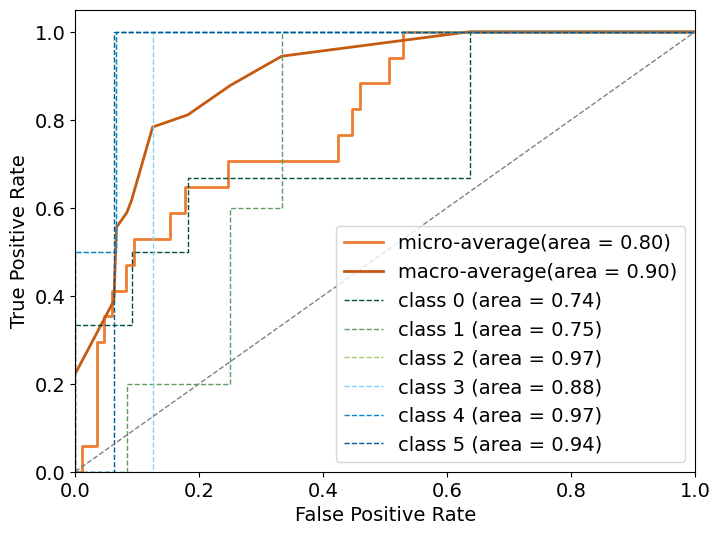

In [12]:
plot_auroc(y_test, y_score, save_fig_path = None)
# plot_auroc(y_test, y_score, save_fig_path = '/results/4d.svg',  mask_font=True)

In [11]:
# save feature importance
fea_masks = model.feature_importances_ != 0
fea_importance = []
# Get feature importances  
importances = model.feature_importances_  
nonzero_fea_idxs = np.where(fea_masks)[0]
# Sort the feature importances in descending order  
sorted_indices = np.argsort(importances)[::-1]  
top_sorted_indices = sorted_indices[:20]

for i, idx in enumerate(top_sorted_indices):  
    print(i, feature_names[idx])
    fea_importance.append([feature_names[idx], importances[idx]])
fea_imp_mdc = pd.DataFrame(data=fea_importance, columns=[ 'feature_name', 'score'])
fea_imp_mdc['seed'] = 0
fea_imp_mdc.to_csv('/results/feature_importance_xps.csv')

0 abs(nankurtosis(Cycle(2/5))[nanmax(E_c(2/4))])
1 abs(nanmax(Cycle(1/5) - Cycle(5/5))[nanmax(W_d(4/4))])
2 abs(nanmin(Cycle(1/5))[nanvar(VQ_d(2/4))])
3 abs(nankurtosis(Cycle(2/5))[nanskew(VQ_d(4/4))])
4 identity(nanmean(Cycle(2/5) - Cycle(3/5))[nanskew(W_c(3/4))])
5 identity(nankurtosis(Cycle(1/5) - Cycle(5/5))[nanmin(W_d(1/4))])
6 abs(nanmean(Cycle(4/5))[nanmax(E_d(3/4))])
7 abs(nanmax(Cycle(1/5))[nanmin(E_d(2/4))])
8 identity(nanvar(Cycle(4/5) - Cycle(5/5))[nanskew(W_d(1/4))])
9 identity(nanmin(Cycle(1/5) - Cycle(3/5))[nanmean(QV_c(3/4))])
10 identity(nanskew(Cycle(1/5) - Cycle(2/5))[nanskew(I_d(1/4))])
11 identity(nanmin(Cycle(4/5) - Cycle(5/5))[nanmean(W_c(3/4))])
12 identity(nanvar(Cycle(4/5))[nanskew(I_c(1/4))])
13 abs(nanmin(Cycle(2/5) - Cycle(3/5))[nanskew(W_d(1/4))])
14 identity(nanskew(Cycle(2/5) - Cycle(4/5))[nanvar(I_c(4/4))])
15 identity(nanmax(Cycle(1/5))[nankurtosis(V_d(3/4))])
16 abs(nankurtosis(Cycle(3/5) - Cycle(4/5))[nanmean(E_c(3/4))])
17 identity(nanvar(Cycle(2/5)

In [16]:
# save feature importance
fea_masks = model.feature_importances_ != 0
fea_importance = []
# Get feature importances  
importances = model.feature_importances_  
nonzero_fea_idxs = np.where(fea_masks)[0]
# Sort the feature importances in descending order  
sorted_indices = np.argsort(importances)[::-1]  
top_sorted_indices = sorted_indices[:20]

for i, idx in enumerate(top_sorted_indices):  
    print(i, feature_names[idx])
    fea_importance.append([feature_names[idx], importances[idx]])
fea_imp_mdc = pd.DataFrame(data=fea_importance, columns=[ 'feature_name', 'score'])
fea_imp_mdc['seed'] = 0
# fea_imp_mdc.to_csv('/results/feature_importance_xps.csv')

0 abs(nankurtosis(Cycle(1/5) - Cycle(4/5))[nanvar(dVdQ_c(2/4))])
1 identity(nanmax(Cycle(3/5))[nankurtosis(W_c(1/4))])
2 abs(nanskew(Cycle(2/5) - Cycle(3/5))[nanmean(I_c(4/4))])
3 abs(nankurtosis(Cycle(1/5))[nanvar(I_c(4/4))])
4 identity(nanskew(Cycle(1/5) - Cycle(5/5))[nanmean(V_c(4/4))])
5 identity(nanvar(Cycle(2/5) - Cycle(4/5))[nanskew(I_c(2/4))])
6 identity(nanmean(Cycle(1/5) - Cycle(5/5))[nanskew(I_d(4/4))])
7 identity(nanmin(Cycle(3/5) - Cycle(5/5))[nanmean(VQ_d(3/4))])
8 abs(nankurtosis(Cycle(3/5) - Cycle(4/5))[nanmean(W_c(1/4))])
9 abs(nankurtosis(Cycle(3/5) - Cycle(4/5))[nanmin(W_d(2/4))])
10 abs(nanmax(Cycle(3/5) - Cycle(4/5))[nanmax(V_d(2/4))])
11 abs(nanskew(Cycle(5/5))[nanmin(QV_d(3/4))])
12 abs(nanskew(Cycle(1/5) - Cycle(2/5))[nanmin(dVdQ_d(2/4))])
13 identity(nanmin(Cycle(4/5) - Cycle(5/5))[nanvar(I_c(4/4))])
14 abs(nanvar(Cycle(2/5) - Cycle(5/5))[nanvar(QV_d(4/4))])
15 abs(nanskew(Cycle(2/5) - Cycle(3/5))[nanvar(W_c(1/4))])
16 identity(nanmax(Cycle(1/5))[nanmean(E_d(2/

## Multi-seeds

In [9]:
y

array([2, 2, 3, 2, 2, 2, 1, 4, 1, 1, 3, 5, 4, 3, 1, 1, 3, 3, 0, 0, 1, 5,
       0, 5, 0, 0, 0, 5, 3, 1, 3, 1, 2, 1, 1, 1, 1, 0, 0, 0, 1, 4, 4, 1,
       3, 1, 4, 4, 0, 0, 3, 0, 0, 5])

In [52]:
import numpy as np
from sklearn.model_selection import train_test_split
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

# Your array
# y = np.array([0,1,2,3,4,3,2,1])
cluster_count = len(np.unique(y))
train_frac = 0.7
# seed = 0 
scores = []
mismatch_dict = {}
match_dict = {}
for seed in range(16):  
    set_seed(seed)

    class_indices = {i: np.where(y == i)[0] for i in range(cluster_count)}
    train_indices = []
    test_indices = []
    for class_id, indices in class_indices.items():
        new_indices = indices.copy()
        random.shuffle(new_indices)
        # print(indices)
        train_idx, test_idx = train_test_split(new_indices, test_size=(1-train_frac), random_state=seed)
        train_indices.extend(train_idx)
        test_indices.extend(test_idx)

    train_indices = np.array(train_indices)
    test_indices = np.array(test_indices)

    y_train = y[train_indices]
    y_test = y[test_indices]
    X_train, X_test = X_ours[train_indices], X_ours[test_indices]

    if (len(np.unique(y_train))!=cluster_count) or (len(np.unique(y_test))!=cluster_count):
        print('not match')
    model = RandomForestClassifier(criterion='entropy', max_depth= 2, max_features= 'log2', n_estimators= 700, random_state=seed)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)

    auroc = roc_auc_score(y_test, y_probs, average='macro', multi_class='ovr')

    accuracy = accuracy_score(y_test, y_pred)
    scores.append([auroc, accuracy])
    print(f'Seed: {seed}, AUROC: {auroc:4f}, accuracy score: {accuracy:.4f}')
    print(f'test indices: {test_indices}')
    print(f'ground truth: {y_test}')
    print(f'prediction  : {y_pred}')
    # print("Train Data:", y_train)
    # print("Test Data:", y_test)
    # print(seed, test_indices)
    # print(seed, y_test)
    mismatch_mask = y_test != y_pred  
    mismatch_indices = test_indices[mismatch_mask]
    match_indices =  test_indices[~mismatch_mask]
    
    for idx in mismatch_indices:
        idx = int(idx)
        
        if idx in mismatch_dict:
            mismatch_dict[idx] +=1
        else:
            mismatch_dict[idx] =1

    for idx in match_indices:
        idx = int(idx)
        
        if idx in match_dict:
            match_dict[idx] +=1
        else:
            match_dict[idx] =1
    # break


Seed: 0, AUROC: 0.633566, accuracy score: 0.2778
test indices: [24 52 51 18 45 31 40 34 33  3  5 44 28 30  7 41 53 11]
ground truth: [0 0 0 0 1 1 1 1 1 2 2 3 3 3 4 4 5 5]
prediction  : [0 0 0 1 0 0 0 1 1 1 1 0 1 1 1 0 0 1]
Seed: 1, AUROC: 0.771221, accuracy score: 0.3889
test indices: [18 51 26 19 35 15 20 36 34  1  4 30 13 17 42 47 23 53]
ground truth: [0 0 0 0 1 1 1 1 1 2 2 3 3 3 4 4 5 5]
prediction  : [1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0]
Seed: 2, AUROC: 0.720598, accuracy score: 0.3889
test indices: [49 48 51 38 36  6  9 14 20  4  0  2 17 10 46  7 23 27]
ground truth: [0 0 0 0 1 1 1 1 1 2 2 3 3 3 4 4 5 5]
prediction  : [0 1 0 1 1 2 1 1 1 2 1 2 1 1 1 1 0 0]
Seed: 3, AUROC: 0.670252, accuracy score: 0.3889
test indices: [49 18 51 19 43  8  6 40  9  0  5 50 17  2 46 47 23 21]
ground truth: [0 0 0 0 1 1 1 1 1 2 2 3 3 3 4 4 5 5]
prediction  : [0 1 0 1 0 1 1 1 1 1 2 0 1 2 0 0 0 0]
Seed: 4, AUROC: 0.773008, accuracy score: 0.3889
test indices: [52 26 18 24  6 34 29  9 43  3 32  2 13 28 42

In [79]:
# sorted_dict = dict(sorted(mismatch_dict.items(), key=lambda item: item[1]))
# # sorted_dict

In [70]:
df1 = pd.DataFrame(list(mismatch_dict.items()), columns=['cell_index', 'mismatch_count'])
df2 = pd.DataFrame(list(match_dict.items()), columns=['cell_index', 'match_count'])



In [71]:
df1 = df1.set_index('cell_index')
df2 = df2.set_index('cell_index')

In [73]:
df_new = pd.concat([df1, df2], axis=1)

In [75]:
df_new = df_new.reset_index()

In [80]:
df_new['label'] = df_new['cell_index'].apply(lambda idx : y[idx])

In [90]:
# df_new.sort_values(by=['match_count'], ascending=False)

In [91]:
# df_new.sort_values(by=['mismatch_count'], ascending=False)

In [49]:
match_dict

{24: 1, 52: 1, 51: 1, 34: 1, 33: 1}

In [ ]:
Seed: 0, AUROC: 0.633566, accuracy score: 0.2778
Seed: 1, AUROC: 0.771221, accuracy score: 0.3889
Seed: 2, AUROC: 0.720598, accuracy score: 0.3889
Seed: 3, AUROC: 0.670252, accuracy score: 0.3889
Seed: 4, AUROC: 0.773008, accuracy score: 0.3889
Seed: 5, AUROC: 0.706965, accuracy score: 0.3889
Seed: 6, AUROC: 0.767727, accuracy score: 0.5000
Seed: 7, AUROC: 0.637828, accuracy score: 0.3333
Seed: 8, AUROC: 0.684566, accuracy score: 0.3889
Seed: 9, AUROC: 0.608586, accuracy score: 0.5000
Seed: 10, AUROC: 0.709028, accuracy score: 0.4444
Seed: 11, AUROC: 0.721594, accuracy score: 0.3333
Seed: 12, AUROC: 0.712366, accuracy score: 0.3333
Seed: 13, AUROC: 0.703125, accuracy score: 0.2778
Seed: 14, AUROC: 0.711149, accuracy score: 0.3333
Seed: 15, AUROC: 0.791732, accuracy score: 0.4444

In [15]:
scores = np.array(scores)
print(f'AUROC mean: {float(scores[:,0].mean()):.4f}, std:{float(scores[:,0].std()):.4f}')
print(f'Accuracy mean: {float(scores[:,1].mean()):.4f}, std:{float(scores[:,1].std()):.4f}')

AUROC mean: 0.7077, std:0.0509
Accuracy mean: 0.3819, std:0.0648


In [41]:
print(f'AUROC mean: {float(scores[:,0].mean()):.4f}, std:{float(scores[:,0].std()):.4f}')
print(f'Accuracy mean: {float(scores[:,1].mean()):.4f}, std:{float(scores[:,1].std()):.4f}')

AUROC mean: 0.7077, std:0.0509
Accuracy mean: 0.3819, std:0.0648


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

cluster_count = len(np.unique(y))

train_frac = 0.7
scores = []
for seed in range(16):
    # seed = 712   
    set_seed(seed)

    # Random train-test split
    N = int(train_frac * len(X_ours))
    perm = np.random.permutation(len(X_ours))
    X_train, X_test = X_ours[perm[:N]], X_ours[perm[N:]]
    y_train, y_test = y[perm[:N]], y[perm[N:]]

    if (len(np.unique(y_train))!=cluster_count) or (len(np.unique(y_test))!=cluster_count):
        print('not match')
    model = RandomForestClassifier(criterion='entropy', max_depth= 2, max_features= 'log2', n_estimators= 700, random_state=seed)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)
    # auroc = roc_auc_score(y_test, y_probs, average='macro', multi_class='ovr')
    # accuracy = accuracy_score(y_test, y_pred)
    # scores.append([auroc, accuracy])
    # print(f'AUROC: {auroc} accuracy score: {accuracy}')
    # y_score = model.predict_proba(X_test)
    try:
        auroc = roc_auc_score(y_test, y_probs, average='macro', multi_class='ovr')
        accuracy = accuracy_score(y_test, y_pred)
        scores.append([auroc, accuracy])
        print(f'AUROC: {auroc} accuracy score: {accuracy}')
        # y_score = model.predict_proba(X_test)
    except:
        print("ValueError: Number of classes in y_true not equal to the number of columns in 'y_score'")


AUROC: 0.6947802197802196 accuracy score: 0.23529411764705882
AUROC: 0.6798430735930737 accuracy score: 0.17647058823529413
not match
ValueError: Number of classes in y_true not equal to the number of columns in 'y_score'
AUROC: 0.6023656898656898 accuracy score: 0.35294117647058826
AUROC: 0.7000000000000001 accuracy score: 0.23529411764705882
not match
ValueError: Number of classes in y_true not equal to the number of columns in 'y_score'
AUROC: 0.7529692529692529 accuracy score: 0.47058823529411764
AUROC: 0.7821097883597884 accuracy score: 0.4117647058823529
AUROC: 0.8116071428571429 accuracy score: 0.47058823529411764
AUROC: 0.7198412698412698 accuracy score: 0.4117647058823529
AUROC: 0.7706800144300144 accuracy score: 0.47058823529411764
AUROC: 0.6862637362637362 accuracy score: 0.23529411764705882
AUROC: 0.79502442002442 accuracy score: 0.29411764705882354
not match
ValueError: Number of classes in y_true not equal to the number of columns in 'y_score'
AUROC: 0.5504426129426129 ac

In [33]:
scores = np.array(scores)

In [30]:
scores

array([], dtype=float64)

# Binary classification

In [86]:
y

array([2, 2, 3, 2, 2, 2, 1, 4, 1, 1, 3, 5, 4, 3, 1, 1, 3, 3, 0, 0, 1, 5,
       0, 5, 0, 0, 0, 5, 3, 1, 3, 1, 2, 1, 1, 1, 1, 0, 0, 0, 1, 4, 4, 1,
       3, 1, 4, 4, 0, 0, 3, 0, 0, 5])

In [128]:
cluster_count = len(np.unique(y))
train_frac = 0.7
scores = []
for class_i in range(cluster_count):
    new_y = np.where(y == class_i, 1, 0)
    print(f'class {class_i}')

    for seed in range(16):
        set_seed(seed)
        new_cluster_count = 2
        class_indices = {i: np.where(new_y == i)[0] for i in range(new_cluster_count)}
        train_indices = []
        test_indices = []
        for class_id, indices in class_indices.items():
            new_indices = indices.copy()
            random.shuffle(new_indices)
            # print(indices)
            train_idx, test_idx = train_test_split(new_indices, test_size=(1-train_frac), random_state=seed)
            train_indices.extend(train_idx)
            test_indices.extend(test_idx)

        train_indices = np.array(train_indices)
        test_indices = np.array(test_indices)

        y_train = new_y[train_indices]
        y_test = new_y[test_indices]
        X_train, X_test = X_ours[train_indices], X_ours[test_indices]

        model = RandomForestClassifier(criterion='entropy', max_depth= 2, max_features= 'log2', n_estimators= 500, random_state=seed)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_probs = model.predict_proba(X_test)
        y_train_probs = model.predict_proba(X_train)
        # y_test_labels = np.argmax(y_probs, axis=1)
        auroc = roc_auc_score(y_test, y_probs[:,1], average='macro', multi_class='ovr')
        accuracy = accuracy_score(y_test, y_pred)
        scores.append([auroc, accuracy])
        print('y_train:',y_train)
        print('y_train_prob:',y_train_probs[:,1])

        print('y_test:',y_test)
        print('y_pred:',y_pred)
        print('y_prob:',y_probs[:,1])
        print(f'AUROC: {auroc} accuracy score: {accuracy}')
        break
    # break

class 0
y_train: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1]
y_train_prob: [0.09634585 0.13670757 0.2333247  0.19866796 0.16520549 0.13854473
 0.12354797 0.0653203  0.12307846 0.10877402 0.1787868  0.0967697
 0.16801057 0.0919756  0.22548755 0.13964731 0.09227959 0.08289264
 0.17411876 0.20003355 0.09934279 0.06653198 0.09136854 0.14567205
 0.22310394 0.10532794 0.1872696  0.12140436 0.59696511 0.65785164
 0.52926304 0.61708832 0.53527074 0.56147115 0.60064304 0.60279206
 0.56907276]
y_test: [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1]
y_pred: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
y_prob: [0.15472343 0.28197937 0.22822634 0.30604281 0.13752675 0.23256077
 0.29748173 0.12473046 0.23832153 0.15772193 0.12694821 0.27360938
 0.13341094 0.40277851 0.28808711 0.34422606 0.38538008]
AUROC: 0.9615384615384616 accuracy score: 0.7647058823529411
class 1
y_train: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
y_train_prob: [0.19092815 0.17781994 0

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

train_frac = 0.7
scores = []

# -------- 外层：遍历每个原始类别 --------
for pos_label in np.unique(y):
    binary_y = (y == pos_label).astype(int)  # 1 = 当前类别，其余 0
    print(f'▶ Class {pos_label} vs. rest')
    
    # 用 StratifiedShuffleSplit 一次性产生 16 组可复现划分
    sss = StratifiedShuffleSplit(
        n_splits=16,
        test_size=1 - train_frac,
        random_state=42        # 控制“划分方案”本身
    )

    # -------- 内层：16 个 seed --------
    for seed, (train_idx, test_idx) in enumerate(sss.split(X_ours, binary_y)):
        X_train, X_test = X_ours[train_idx], X_ours[test_idx]
        y_train, y_test = binary_y[train_idx], binary_y[test_idx]

        # 每个 seed 内部的模型随机性再用 seed 控制
        clf = RandomForestClassifier(
            n_estimators=500,
            criterion='entropy',
            max_depth=2,
            max_features='log2',
            random_state=seed
        )
        clf.fit(X_train, y_train)

        prob_test = clf.predict_proba(X_test)[:, 1]
        pred_test = clf.predict(X_test)

        auroc = roc_auc_score(y_test, prob_test)
        acc = accuracy_score(y_test, pred_test)
        scores.append({'class': pos_label, 'seed': seed,
                       'auroc': auroc, 'acc': acc})

        print(f'  seed={seed:2d}  AUROC={auroc:.4f}  ACC={acc:.4f}')
        break

▶ Class 0 vs. rest


  seed= 0  AUROC=0.7308  ACC=0.8235
▶ Class 1 vs. rest
  seed= 0  AUROC=0.8333  ACC=0.7059
▶ Class 2 vs. rest
  seed= 0  AUROC=1.0000  ACC=0.8824
▶ Class 3 vs. rest
  seed= 0  AUROC=0.4524  ACC=0.8235
▶ Class 4 vs. rest
  seed= 0  AUROC=0.5333  ACC=0.8824
▶ Class 5 vs. rest
  seed= 0  AUROC=0.8000  ACC=0.8824


In [121]:
y_train

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1])

In [111]:
class_indices

{0: array([18, 19, 22, 24, 25, 26, 37, 38, 39, 48, 49, 51, 52]),
 1: array([ 6,  8,  9, 14, 15, 20, 29, 31, 33, 34, 35, 36, 40, 43, 45])}

In [105]:
y_test

array([1, 1, 1, 1, 0, 0, 0, 0, 0])

In [106]:
y_pred

array([1, 1, 1, 0, 1, 1, 1, 0, 0])

In [102]:
y_train

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

# Your array
# y = np.array([0,1,2,3,4,3,2,1])
cluster_count = len(np.unique(y))
train_frac = 0.7
# seed = 0 
scores = []
mismatch_dict = {}
match_dict = {}
for seed in range(16):  
    set_seed(seed)

    class_indices = {i: np.where(y == i)[0] for i in range(cluster_count)}
    train_indices = []
    test_indices = []
    for class_id, indices in class_indices.items():
        new_indices = indices.copy()
        random.shuffle(new_indices)
        # print(indices)
        train_idx, test_idx = train_test_split(new_indices, test_size=(1-train_frac), random_state=seed)
        train_indices.extend(train_idx)
        test_indices.extend(test_idx)

    train_indices = np.array(train_indices)
    test_indices = np.array(test_indices)

    y_train = y[train_indices]
    y_test = y[test_indices]
    X_train, X_test = X_ours[train_indices], X_ours[test_indices]

    if (len(np.unique(y_train))!=cluster_count) or (len(np.unique(y_test))!=cluster_count):
        print('not match')
    model = RandomForestClassifier(criterion='entropy', max_depth= 2, max_features= 'log2', n_estimators= 700, random_state=seed)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)

    auroc = roc_auc_score(y_test, y_probs, average='macro', multi_class='ovr')

    accuracy = accuracy_score(y_test, y_pred)
    scores.append([auroc, accuracy])
    print(f'Seed: {seed}, AUROC: {auroc:4f}, accuracy score: {accuracy:.4f}')
    print(f'test indices: {test_indices}')
    print(f'ground truth: {y_test}')
    print(f'prediction  : {y_pred}')
    # print("Train Data:", y_train)
    # print("Test Data:", y_test)
    # print(seed, test_indices)
    # print(seed, y_test)
    mismatch_mask = y_test != y_pred  
    mismatch_indices = test_indices[mismatch_mask]
    match_indices =  test_indices[~mismatch_mask]
    
    for idx in mismatch_indices:
        idx = int(idx)
        
        if idx in mismatch_dict:
            mismatch_dict[idx] +=1
        else:
            mismatch_dict[idx] =1

    for idx in match_indices:
        idx = int(idx)
        
        if idx in match_dict:
            match_dict[idx] +=1
        else:
            match_dict[idx] =1
    # break


(0.34313725490196073, 0.10141255326263333)

(0.712160601743935, 0.07481668414740626)